# Imports

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
print(sys.executable)

C:\Users\erics\OneDrive\Bureau\Cursus\3e_ESGI\s2\PA\projet_annuel\projet_annuel_IABD\python_client\.venv\Scripts\python.exe


In [28]:
import numpy as np
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    void* create_rosenblatt(
        size_t n_features,
        float learning_rate,
        float bias,
        uint64_t seed
    );

    void train_rosenblatt(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const int* y,
        size_t y_len,
        size_t epochs
    );

    float* predict_rosenblatt(
        void* rosenblatt,
        const float* x,
        size_t rows,
        size_t cols
    );
    
    float* get_weights_rosenblatt(
        void* rosenblatt
    );
    
    typedef struct {
        float* data;
        size_t rows;
        size_t cols;
    } MatrixFFIRos;
    
    MatrixFFIRos* transforming_ros(
        const float* x,
        size_t rows,
        size_t cols
    );
    
    void release_matrix_ffi(
        MatrixFFIRos* matrix
    );
    
""", override=True)
if os.name != "nt":
    lib_path = os.path.abspath("../felidae_classifier/target/release/libfelidae_classifier.so")
else:
    lib_path = os.path.abspath("../felidae_classifier/target/release/felidae_classifier.dll")
lib = ffi.dlopen(lib_path)
def score(features, w, b):
    total = b
    for i in range(len(w)):
        total = total + w[i] * features[i]
    return total

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

[ 1 -1 -1]
OK
bias : 10.006341
weights : [ 6.766319e-04 -6.007942e+00]


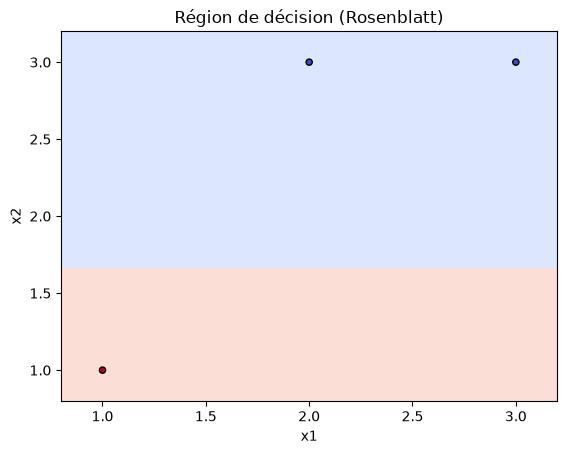

In [30]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])


rosenblatt = lib.create_rosenblatt(
    X.shape[1],
    1.0,
    1.0,
    200
)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)

lib.train_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1000
)

linear_test = lib.predict_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1]
)

pred_linear = np.frombuffer(
    ffi.buffer(linear_test, X.shape[0] * ffi.sizeof("float")),
    dtype = np.float32
)
pred_linear = np.where(pred_linear > 0, 1, -1)
print(pred_linear)
if np.array_equal(pred_linear, Y):
    print("OK")
else:
    print("KO")



n_features = X.shape[1]

weights_ptr = lib.get_weights_rosenblatt(rosenblatt)
weights_buffer = np.frombuffer(
    ffi.buffer(weights_ptr, (n_features + 1) * ffi.sizeof("float")),
    dtype=np.float32
)

bias_weight = weights_buffer[0]
w = weights_buffer[1:] 

print("bias :", bias_weight)
print("weights :", w)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = score([xx, yy], w, bias_weight)
Z = np.where(Z > 0, 1, -1)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=[-1.5, 0, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", edgecolors="k", s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Région de décision (Rosenblatt)")
plt.show()


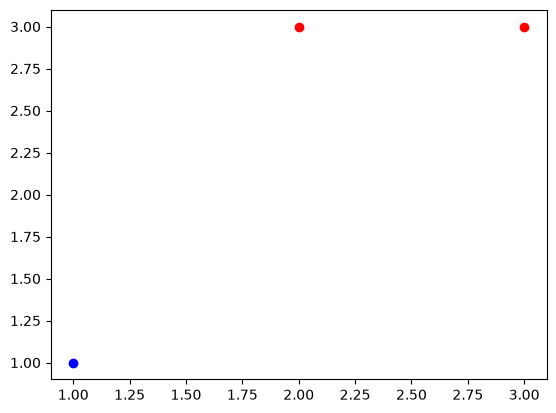

<Figure size 640x480 with 0 Axes>

In [32]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
OK
bias : 14.006341
weights : [-1.5169423 -5.7097588]


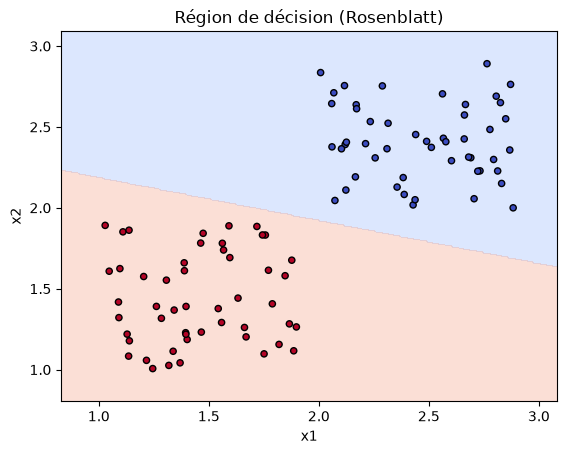

In [36]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])


rosenblatt = lib.create_rosenblatt(
    X.shape[1],
    1.0,
    1.0,
    200
)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)

lib.train_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1000
)

linear_test = lib.predict_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1]
)

pred_linear = np.frombuffer(
    ffi.buffer(linear_test, X.shape[0] * ffi.sizeof("float")),
    dtype = np.float32
)
pred_linear = np.where(pred_linear > 0, 1, -1)
print(pred_linear)
if np.array_equal(pred_linear, Y.flatten()):
    print("OK")
else:
    print("KO")

n_features = X.shape[1]
weights_ptr = lib.get_weights_rosenblatt(rosenblatt)
weights_buffer = np.frombuffer(
    ffi.buffer(weights_ptr, (n_features + 1) * ffi.sizeof("float")),
    dtype=np.float32
)
bias_weight = weights_buffer[0]
w = weights_buffer[1:]
print("bias :", bias_weight)
print("weights :", w)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = score([xx, yy], w, bias_weight)
Z = np.where(Z > 0, 1, -1)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=[-1.5, 0, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", edgecolors="k", s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Région de décision (Rosenblatt)")
plt.show()

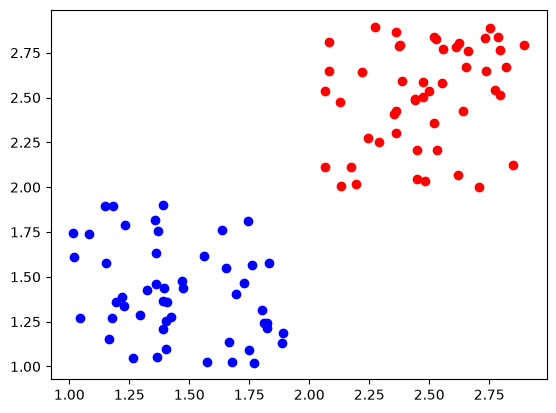

<Figure size 640x480 with 0 Axes>

In [35]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

[ 0.01803583  0.01735037 -0.01365897 -0.02834794]
[ 1  1 -1 -1]
OK
bias : -0.013658974
weights : [ 0.02067652  0.01205807  0.01101829 -0.07739311  0.01895127]


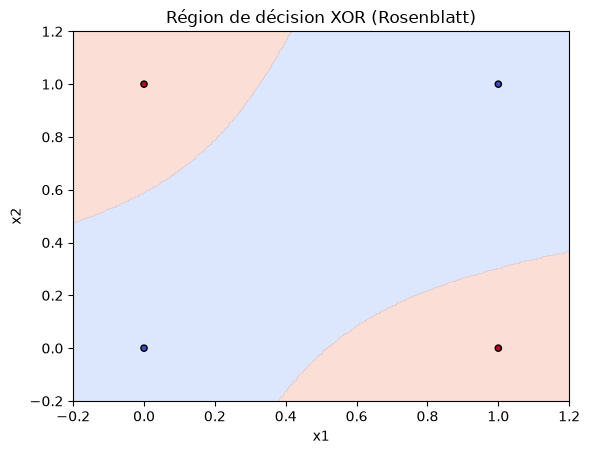

Nombre de features après transformation : 5
Poids appris : [ 0.02067652  0.01205807  0.01101829 -0.07739311  0.01895127]
Biais appris : -0.013658974


In [8]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)
result = lib.transforming_ros(X_ptr, X.shape[0], X.shape[1])
new_X = np.frombuffer(
    ffi.buffer(result.data, result.rows * result.cols * ffi.sizeof("float")),
    dtype = np.float32
).reshape(result.rows, result.cols)

rosenblatt = lib.create_rosenblatt(
    result.cols,
    0.01,
    1.0,
    200
)

lib.train_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols,
    Y_ptr,
    Y.shape[0],
    500
)

pred = lib.predict_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols
)

pred_result = np.frombuffer(
    ffi.buffer(pred, result.rows * ffi.sizeof("float")),
    dtype = np.float32
)
print(pred_result)
pred_result = np.where(pred_result > 0, 1, -1)
print(pred_result)
if np.array_equal(pred_result, Y):
    print("OK")
else:
    print("KO")


n_features = result.cols
weights_ptr = lib.get_weights_rosenblatt(rosenblatt)
weights_buffer = np.frombuffer(
    ffi.buffer(weights_ptr, (n_features + 1) * ffi.sizeof("float")),
    dtype=np.float32
)
bias_weight = weights_buffer[0]
w = weights_buffer[1:]
print("bias :", bias_weight)
print("weights :", w)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

n_points = xx.shape[0] * xx.shape[1]
grid_points = np.zeros((n_points, 2), dtype=np.float32)

xx_flat = xx.ravel()
yy_flat = yy.ravel()

for i in range(n_points):
    grid_points[i, 0] = xx_flat[i]
    grid_points[i, 1] = yy_flat[i]

grid_ptr = ffi.from_buffer("float[]", grid_points)
grid_result = lib.transforming_ros(grid_ptr, grid_points.shape[0], grid_points.shape[1])

grid_transformed = np.frombuffer(
    ffi.buffer(grid_result.data, grid_result.rows * grid_result.cols * ffi.sizeof("float")),
    dtype=np.float32
).reshape(grid_result.rows, grid_result.cols)

features_grid = []
for i in range(n_features):
    colonne = grid_transformed[:, i]
    colonne_grille = colonne.reshape(xx.shape)
    features_grid.append(colonne_grille)
    
Z = score(features_grid, w, bias_weight)
Z = np.where(Z > 0, 1, -1)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=[-1.5, 0, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", edgecolors="k", s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Région de décision XOR (Rosenblatt)")
plt.show()

print("Nombre de features après transformation :", result.cols)
print("Poids appris :", w)
print("Biais appris :", bias_weight)

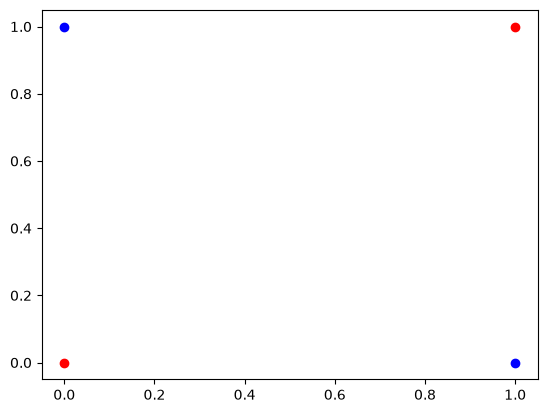

<Figure size 640x480 with 0 Axes>

In [75]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()


### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

[-1  1  1  1 -1  1  1 -1 -1 -1 -1  1  1  1 -1  1  1 -1 -1  1  1  1  1 -1
 -1  1  1 -1  1 -1 -1 -1 -1 -1 -1  1 -1  1  1 -1 -1 -1  1 -1  1 -1 -1 -1
  1  1 -1 -1  1  1  1  1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1  1 -1  1
  1 -1  1 -1 -1  1  1 -1  1 -1  1  1 -1  1 -1  1  1  1 -1 -1 -1 -1  1  1
  1 -1 -1 -1 -1 -1 -1  1 -1  1  1  1  1  1 -1 -1 -1 -1  1  1  1 -1 -1  1
 -1 -1  1 -1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1 -1  1  1 -1 -1 -1
  1 -1  1 -1  1  1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1  1 -1 -1 -1 -1
  1  1  1  1 -1 -1 -1  1 -1 -1 -1 -1  1  1 -1 -1 -1  1  1  1 -1  1  1  1
 -1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1 -1 -1  1 -1 -1 -1  1  1 -1  1 -1 -1
  1  1  1  1  1  1 -1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1 -1
 -1 -1 -1  1 -1  1  1  1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1
 -1  1 -1  1 -1  1 -1  1  1 -1 -1 -1  1  1  1  1 -1 -1  1  1 -1  1 -1 -1
  1 -1  1  1 -1  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1
 -1  1 -1  1 -1 -1 -1  1 -1  1  1  1 -1  1 -1 -1  1

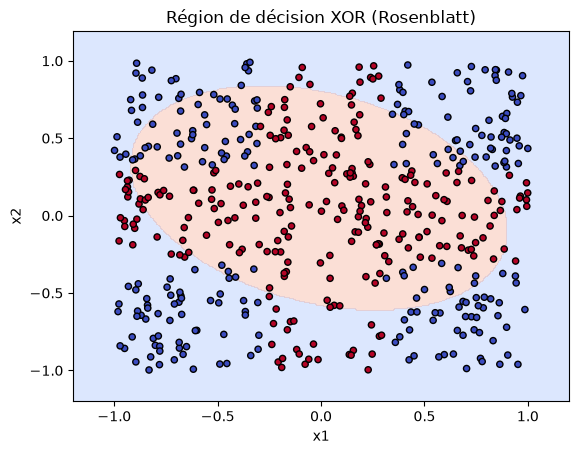

Nombre de features après transformation : 5
Poids appris : [ 0.00236323  0.01262896 -0.03572682 -0.02677053 -0.05653258]
Biais appris : 0.026341029


In [10]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
print(Y)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)
result = lib.transforming_ros(X_ptr, X.shape[0], X.shape[1])
new_X = np.frombuffer(
    ffi.buffer(result.data, result.rows * result.cols * ffi.sizeof("float")),
    dtype = np.float32
).reshape(result.rows, result.cols)

rosenblatt = lib.create_rosenblatt(
    result.cols,
    0.01,
    1.0,
    200
)

lib.train_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols,
    Y_ptr,
    Y.shape[0],
    500
)

pred = lib.predict_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols
)

pred_result = np.frombuffer(
    ffi.buffer(pred, result.rows * ffi.sizeof("float")),
    dtype = np.float32
)
print(pred_result)
pred_result = np.where(pred_result > 0, 1, -1)
print(pred_result)
if np.array_equal(pred_result, Y.flatten()):
    print("OK")
else:
    print("KO")




n_features = result.cols
weights_ptr = lib.get_weights_rosenblatt(rosenblatt)
weights_buffer = np.frombuffer(
    ffi.buffer(weights_ptr, (n_features + 1) * ffi.sizeof("float")),
    dtype=np.float32
)
bias_weight = weights_buffer[0]
w = weights_buffer[1:]
print("bias :", bias_weight)
print("weights :", w)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

n_points = xx.shape[0] * xx.shape[1]
grid_points = np.zeros((n_points, 2), dtype=np.float32)

xx_flat = xx.ravel()
yy_flat = yy.ravel()

for i in range(n_points):
    grid_points[i, 0] = xx_flat[i]
    grid_points[i, 1] = yy_flat[i]

grid_ptr = ffi.from_buffer("float[]", grid_points)
grid_result = lib.transforming_ros(grid_ptr, grid_points.shape[0], grid_points.shape[1])

grid_transformed = np.frombuffer(
    ffi.buffer(grid_result.data, grid_result.rows * grid_result.cols * ffi.sizeof("float")),
    dtype=np.float32
).reshape(grid_result.rows, grid_result.cols)

features_grid = []
for i in range(n_features):
    colonne = grid_transformed[:, i]
    colonne_grille = colonne.reshape(xx.shape)
    features_grid.append(colonne_grille)
    
Z = score(features_grid, w, bias_weight)
Z = np.where(Z > 0, 1, -1)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=[-1.5, 0, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", edgecolors="k", s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Région de décision XOR (Rosenblatt)")
plt.show()

print("Nombre de features après transformation :", result.cols)
print("Poids appris :", w)
print("Biais appris :", bias_weight)

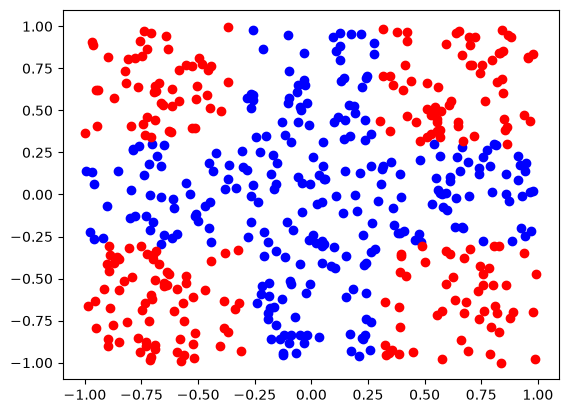

<Figure size 640x480 with 0 Axes>

In [47]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    void* create_rosenblatt_classifier(
        size_t n_features,
        float learning_rate,
        float bias_cat,
        float bias_lion,
        float bias_cheetah,
        uint64_t seed
    );

    void train_classifier(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const size_t* y,
        size_t y_len,
        size_t epochs
    );

    size_t* predict_classifier(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const size_t* y,
        size_t y_len
    );

    float* get_weights_classifier(void* classifier);
    
    typedef struct {
        float* data;
        size_t rows;
        size_t cols;
    } MatrixFFI;
    MatrixFFI* transforming(void* classifier, const float* x, size_t rows, size_t cols);
    void release_matrix_ffi(MatrixFFI* matrix);
    
""", override=True)

lib = ffi.dlopen(lib_path)

y de base [[-1  1 -1]
 [ 1 -1 -1]
 [-1 -1  1]
 ...
 [-1 -1  1]
 [-1 -1  1]
 [-1  1 -1]]
y ffi  [1 0 2 2 1 1 1 0 2 1 1 0 2 0 1 0 1 1 1 1 0 1 0 2 1 0 0 2 0 1 1 0 1 1 2 0 2
 0 1 1 1 0 2 2 1 0 1 1 1 0 2 0 0 1 0 2 0 0 1 0 0 2 0 1 1 2 2 0 1 2 0 2 0 2
 1 0 1 1 0 0 1 2 2 1 1 1 1 1 1 2 2 1 1 1 0 1 2 1 1 0 1 1 1 0 1 2 1 1 2 1 2
 0 2 1 1 2 2 1 2 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 2 1 2 2 1 0 0 0 2 1 1 2
 1 2 2 1 2 2 1 1 1 0 1 2 0 2 0 1 1 1 2 1 2 1 2 2 2 1 0 1 0 1 1 0 1 1 2 1 0
 1 1 2 0 1 1 1 2 1 1 0 0 1 2 2 0 1 1 1 1 0 1 2 2 1 0 1 0 1 1 1 1 2 2 2 2 2
 1 1 2 1 2 0 1 1 1 1 2 1 0 2 1 1 0 0 2 1 1 1 1 0 1 1 0 1 2 1 0 1 1 1 1 2 0
 2 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 2 1 1 0 2 1 2 2 1 2 0 1 2 1 2 1 2 2 2 2
 1 1 0 1 1 2 1 1 1 2 1 1 2 1 2 0 1 2 1 1 1 1 0 0 0 1 1 1 1 1 2 1 0 2 1 1 1
 0 1 1 1 1 1 2 1 1 0 2 1 1 1 1 0 1 1 1 1 0 1 0 1 2 0 0 0 0 1 1 0 1 1 0 1 1
 1 1 2 1 1 1 1 1 1 1 2 2 0 1 1 1 1 0 1 1 1 2 0 0 1 2 0 1 0 1 2 2 1]
prediction form [1 0 2 2 1 1 1 0 2 1 1 0 2 0 1 0 1 1 1 1 0 1 0 2 1 0 0 2 0 1 1 0 1 1 2 

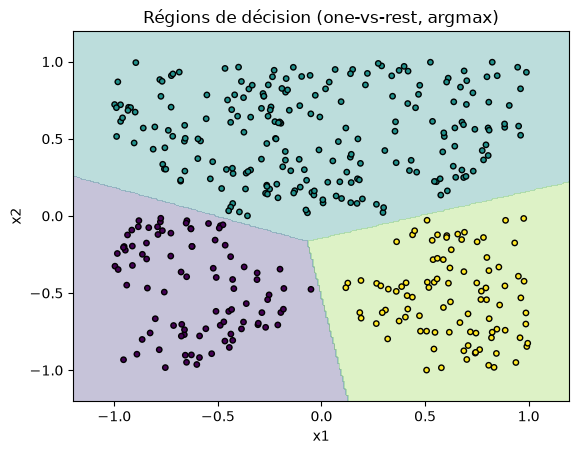

In [39]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

print("y de base",Y)

X_ffi = np.ascontiguousarray(X, dtype=np.float32)
Y_ffi = np.ascontiguousarray(np.argmax(Y, axis=1), dtype=np.uint64)
print("y ffi ",Y_ffi)
X_ptr = ffi.from_buffer("float[]", X_ffi)
Y_ptr = ffi.from_buffer("size_t[]", Y_ffi)

classifier = lib.create_rosenblatt_classifier(X.shape[1], 0.01, 1.0, 1.0, 1.0, 200)
lib.train_classifier(
    classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0],
    100
)

pred_brut = lib.predict_classifier(classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0]
)

pred_form = np.frombuffer(
    ffi.buffer(pred_brut, X_ffi.shape[0] * ffi.sizeof("size_t")),
    dtype=np.uintp
)
print("prediction form",pred_form)

if np.array_equal(pred_form.flatten(), Y_ffi):
    print("OK")
else:
    print("KO")


n_features = X_ffi.shape[1]
block_size = n_features + 1 

weights_ptr = lib.get_weights_classifier(classifier)
weights_buffer = np.frombuffer(
    ffi.buffer(weights_ptr, 3 * block_size * ffi.sizeof("float")),
    dtype=np.float32
)

cat_w = weights_buffer[0:block_size]
lion_w = weights_buffer[block_size:2*block_size]
cheetah_w = weights_buffer[2*block_size:3*block_size]

bias_cat, w_cat = cat_w[0], cat_w[1:]
bias_lion, w_lion = lion_w[0], lion_w[1:]
bias_cheetah, w_cheetah = cheetah_w[0], cheetah_w[1:]

print("cat     :", bias_cat, w_cat)
print("lion    :", bias_lion, w_lion)
print("cheetah :", bias_cheetah, w_cheetah)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

s_cat = score([xx, yy,], w_cat, bias_cat)
s_lion = score([xx, yy,], w_lion, bias_lion)
s_cheetah = score([xx, yy,], w_cheetah, bias_cheetah)

Z = np.argmax(np.stack([s_cat, s_lion, s_cheetah]), axis=0)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis", levels=[-0.5, 0.5, 1.5, 2.5])
plt.scatter(X[:, 0], X[:, 1], c=Y_ffi, cmap="viridis", edgecolors="k", s=15)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Régions de décision (one-vs-rest, argmax)")
plt.show()

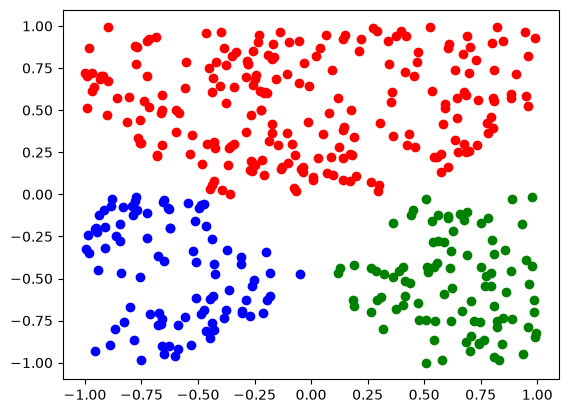

<Figure size 640x480 with 0 Axes>

In [40]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

y de base [[-1 -1  1]
 [ 1 -1 -1]
 [-1 -1  1]
 ...
 [-1 -1  1]
 [-1 -1  1]
 [-1 -1  1]]
y ffi  [2 0 2 1 2 2 2 2 0 0 0 2 2 0 2 2 2 1 1 2 1 0 2 1 1 0 2 1 0 0 1 2 2 1 0 2 2
 0 0 2 2 2 1 0 1 1 0 0 2 2 2 2 2 2 1 2 2 0 0 2 1 0 2 2 0 2 0 1 2 2 1 0 0 1
 2 2 2 2 2 2 1 1 2 0 2 1 2 0 2 0 2 0 1 1 2 2 0 1 0 2 0 0 2 0 0 2 0 2 2 0 2
 2 1 2 2 2 0 2 1 2 0 2 1 2 1 1 0 2 2 2 2 0 2 0 1 2 2 1 2 1 2 2 0 2 0 2 2 2
 2 1 2 0 1 0 0 1 2 1 2 1 1 2 2 2 2 0 2 2 0 0 1 0 2 2 0 0 2 1 2 0 2 1 1 2 0
 0 2 2 2 2 0 2 1 2 2 2 1 2 2 2 1 2 2 1 0 0 2 1 0 2 2 1 2 2 0 2 1 0 2 2 1 2
 1 2 1 0 1 2 2 1 2 0 2 2 0 1 1 2 2 2 0 1 0 2 2 0 2 2 1 2 0 2 2 2 2 1 0 0 0
 0 1 0 1 1 2 2 1 0 1 2 2 0 2 1 0 0 0 0 2 2 0 0 1 2 2 1 1 2 2 2 2 0 1 0 2 2
 1 0 2 2 2 0 0 2 0 0 1 1 0 2 2 1 0 2 0 1 0 1 0 0 2 2 2 1 0 2 2 2 2 2 2 2 1
 1 1 1 2 1 2 1 1 1 1 1 2 1 1 0 2 1 1 2 2 0 2 2 0 0 2 1 0 2 2 2 2 1 0 0 1 1
 1 2 1 2 1 2 2 2 2 0 0 0 2 2 1 1 2 1 2 2 2 1 1 1 1 2 2 2 1 2 0 2 0 1 1 2 0
 1 1 2 2 2 1 2 2 0 0 1 2 1 1 1 2 2 2 0 1 2 2 2 2 1 0 1 2 2 0 0 1 1 0 2 1 0
 1 2 

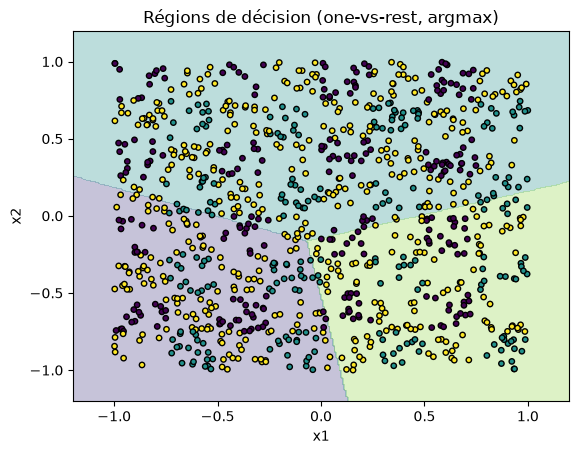

In [41]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

print("y de base",Y)

X_ffi = np.ascontiguousarray(X, dtype=np.float32)
Y_ffi = np.ascontiguousarray(np.argmax(Y, axis=1), dtype=np.uint64)
print("y ffi ",Y_ffi)
X_ptr = ffi.from_buffer("float[]", X_ffi)
Y_ptr = ffi.from_buffer("size_t[]", Y_ffi)

classifier = lib.create_rosenblatt_classifier(X.shape[1], 0.01, 1.0, 1.0, 1.0, 200)
lib.train_classifier(
    classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0],
    100
)

pred_brut = lib.predict_classifier(classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0]
)

pred_form = np.frombuffer(
    ffi.buffer(pred_brut, X_ffi.shape[0] * ffi.sizeof("size_t")),
    dtype=np.uintp
)
print("prediction form",pred_form)

if np.array_equal(pred_form.flatten(), Y_ffi):
    print("OK")
else:
    print("KO")


cat_w = weights_buffer[0:block_size]
lion_w = weights_buffer[block_size:2*block_size]
cheetah_w = weights_buffer[2*block_size:3*block_size]

bias_cat, w_cat = cat_w[0], cat_w[1:]
bias_lion, w_lion = lion_w[0], lion_w[1:]
bias_cheetah, w_cheetah = cheetah_w[0], cheetah_w[1:]

print("cat     :", bias_cat, w_cat)
print("lion    :", bias_lion, w_lion)
print("cheetah :", bias_cheetah, w_cheetah)


x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

s_cat = score([xx, yy], w_cat, bias_cat)
s_lion = score([xx, yy], w_lion, bias_lion)
s_cheetah = score([xx, yy], w_cheetah, bias_cheetah)

Z = np.argmax(np.stack([s_cat, s_lion, s_cheetah]), axis=0)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis", levels=[-0.5, 0.5, 1.5, 2.5])
plt.scatter(X[:, 0], X[:, 1], c=Y_ffi, cmap="viridis", edgecolors="k", s=15)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Régions de décision (one-vs-rest, argmax)")
plt.show()


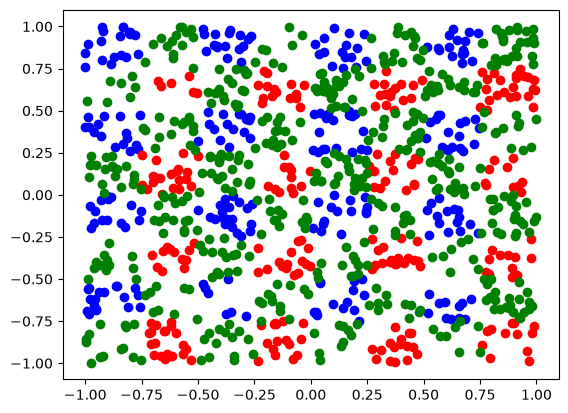

<Figure size 640x480 with 0 Axes>

In [69]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [14]:
import matplotlib.pyplot as plt
import numpy as np

import os
import numpy as np
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    typedef struct{
        float* data;
        size_t rows;
        size_t cols;
    }MatrixFFIRegression;
    
    void* create_regression(
        size_t nb_feature
    );

    void fit_regression(
        void* regression,
        const float* x,
        size_t x_rows,
        size_t x_cols,
        const float* y,
        size_t y_len,
        float bias  
    );
    

    MatrixFFIRegression* predict_regression(
        void* regression,
        const float* x,
        size_t x_rows,
        size_t x_cols,
        float bias
    );

    void release_matrix_ffi(
        MatrixFFIRegression* matrix
    );
""", override = True)

lib = ffi.dlopen(lib_path)

OK


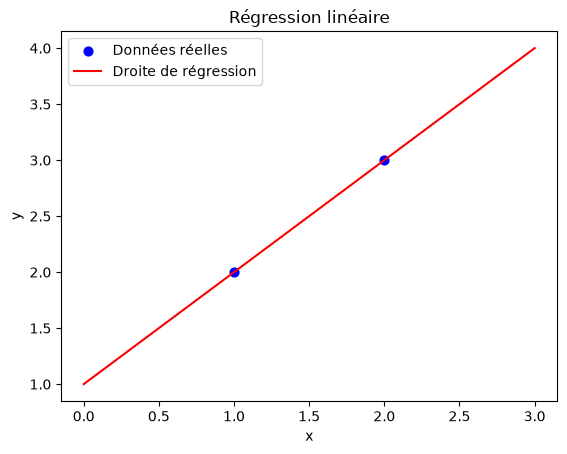

In [15]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)

if np.array_equal(prediction_form, Y):
    print("OK")
else:
    print("KO")


x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 100).astype(np.float32).reshape(-1, 1)

x_line_ptr = ffi.from_buffer("float[]", x_line)

line_prediction = lib.predict_regression(
    regression,
    x_line_ptr,
    x_line.shape[0],
    x_line.shape[1],
    1.0
)

y_line = np.frombuffer(
    ffi.buffer(
        line_prediction.data,
        line_prediction.rows * line_prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)

plt.scatter(X[:, 0], Y, c="blue", label="Données réelles", s=40)
plt.plot(x_line[:, 0], y_line, "r-", label="Droite de régression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Régression linéaire")
plt.legend()
plt.show()

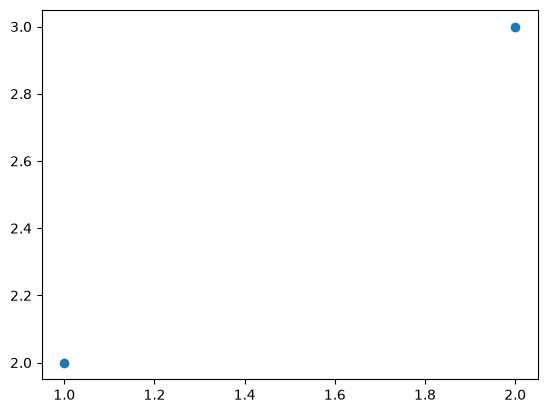

<Figure size 640x480 with 0 Axes>

In [13]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

[2.  3.  2.5]
[2.2499995 2.4999995 2.7499995]
OK


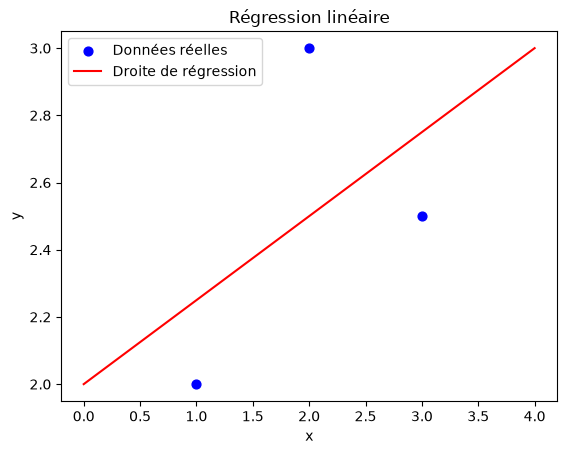

In [16]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])


X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)


print(Y)
print(prediction_form)

if np.allclose(prediction_form, Y, atol=0.5):
    print("OK")
else:
    print("KO")


x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 100).astype(np.float32).reshape(-1, 1)

x_line_ptr = ffi.from_buffer("float[]", x_line)

line_prediction = lib.predict_regression(
    regression,
    x_line_ptr,
    x_line.shape[0],
    x_line.shape[1],
    1.0
)

y_line = np.frombuffer(
    ffi.buffer(
        line_prediction.data,
        line_prediction.rows * line_prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)

plt.scatter(X[:, 0], Y, c="blue", label="Données réelles", s=40)
plt.plot(x_line[:, 0], y_line, "r-", label="Droite de régression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Régression linéaire")
plt.legend()
plt.show()

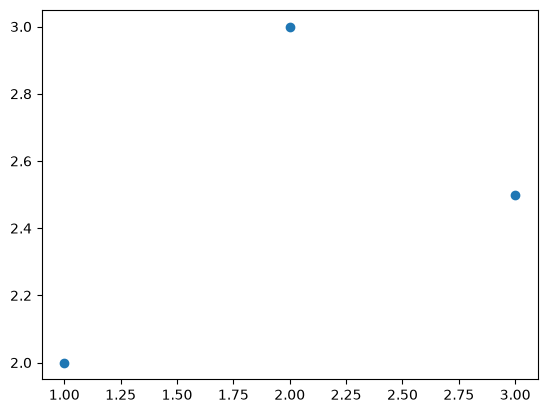

<Figure size 640x480 with 0 Axes>

In [75]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

OK


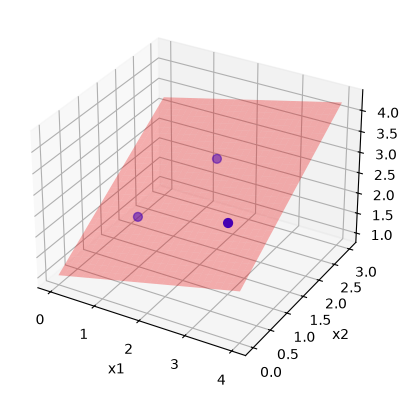

In [17]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])


X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)



if np.allclose(prediction_form, Y):
    print("OK")
else:
    print("KO")
    
from mpl_toolkits.mplot3d import Axes3D

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 30), np.linspace(x2_min, x2_max, 30))

grid_points = np.column_stack([xx1.ravel(), xx2.ravel()]).astype(np.float32)
grid_ptr = ffi.from_buffer("float[]", grid_points)

grid_prediction = lib.predict_regression(
    regression, grid_ptr, grid_points.shape[0], grid_points.shape[1], 1.0
)
zz = np.frombuffer(
    ffi.buffer(grid_prediction.data, grid_prediction.rows * grid_prediction.cols * ffi.sizeof("float")),
    dtype=np.float32
).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], Y, c="blue", s=40, label="Données réelles")
ax.plot_surface(xx1, xx2, zz, alpha=0.3, color="red")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
plt.show()

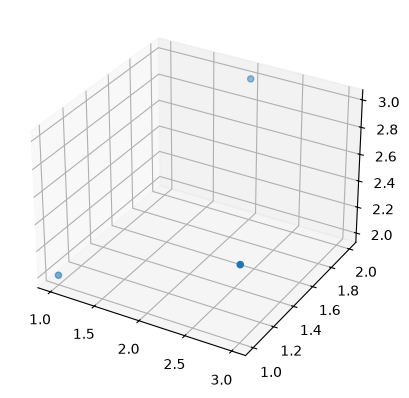

<Figure size 640x480 with 0 Axes>

In [18]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [3]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

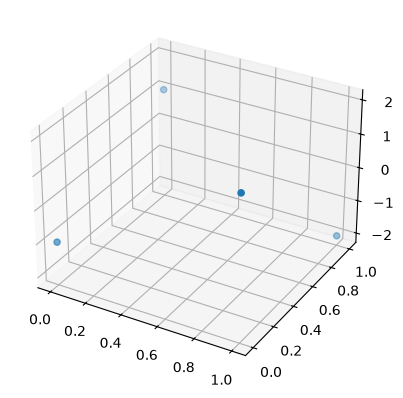

<Figure size 640x480 with 0 Axes>

In [23]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [19]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])


X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)



if np.allclose(prediction_form, Y):
    print("OK")
else:
    print("KO")

KO


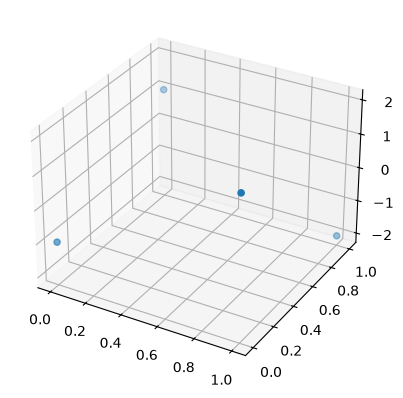

<Figure size 640x480 with 0 Axes>

In [20]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

## MLP Setup :

In [2]:
from cffi import FFI
ffi_mlp = FFI()
ffi_mlp.cdef("""
    void* mlp_create(
        const uint32_t* layer_sizes,
        size_t n_layers,
        const char* activation,
        const char* output_activation
    );
    void mlp_train(
        void* mlp,
        const float* x_data, size_t x_rows, size_t x_cols,
        const float* y_data, size_t y_rows, size_t y_cols,
        size_t epochs,
        float learning_rate
    );
    void mlp_predict_classes(
        const void* mlp,
        const float* x_data, size_t x_rows, size_t x_cols,
        uint32_t* out_predictions
    );
    void mlp_predict_raw(
        const void* mlp,
        const float* x_data, size_t x_rows, size_t x_cols,
        float* out_predictions
    );
    void mlp_destroy(void* mlp);
""", override=True)

if os.name != "Windows":
    lib_path = os.path.abspath("../felidae_classifier/target/release/libfelidae_classifier.so")
else:
    lib_path = os.path.abspath("../felidae_classifier/target/release/felidae_classifier.dll")

mlp_lib = ffi_mlp.dlopen(lib_path)

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [ ]:
X = np.array([[1,1],[2,3],[3,3]])
Y = np.array([1,-1,-1])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 4, 1])
mlp = mlp_lib.mlp_create(layers, 3, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    10000, 0.1)

# predict on training points
out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.where(np.array(list(out)) > 0, 1, -1)
print("OK" if np.array_equal(preds, Y) else "KO")

# predict on grid
x0 = np.linspace(X_f[:,0].min()-0.5, X_f[:,0].max()+0.5, 200)
x1 = np.linspace(X_f[:,1].min()-0.5, X_f[:,1].max()+0.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("float[]", grid.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.where(np.array(list(grid_out)) > 0, 1, -1).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

# plot
plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='bwr')
plt.scatter(X_f[Y==1,0], X_f[Y==1,1], color='red', label='1', zorder=3)
plt.scatter(X_f[Y==-1,0], X_f[Y==-1,1], color='blue', label='-1', zorder=3)
plt.legend()
plt.title("MLP - Linear Simple")
plt.show()
plt.clf()

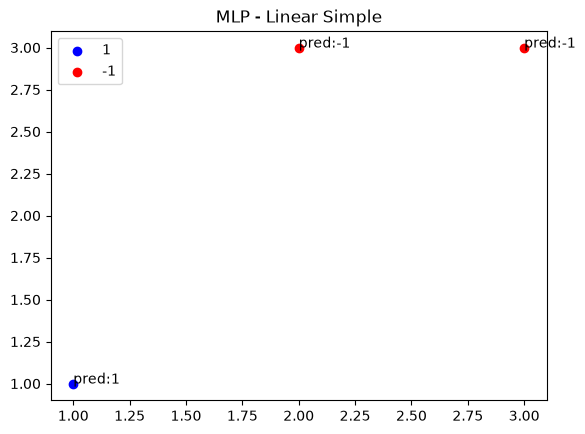

<Figure size 640x480 with 0 Axes>

In [4]:
plt.scatter(X[0,0], X[0,1], color='blue', label='1')
plt.scatter(X[1:,0], X[1:,1], color='red', label='-1')
colors = ['blue' if p == 1 else 'red' for p in preds]
for i in range(len(X)):
    plt.annotate(f'pred:{preds[i]}', (X[i,0], X[i,1]))
plt.legend()plt.title("MLP - Linear Simple")
plt.show()
plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [ ]:
X = np.concatenate([np.random.random((50,2))*0.9+np.array([1,1]), np.random.random((50,2))*0.9+np.array([2,2])])
Y = np.concatenate([np.ones(50), np.ones(50)*-1.0])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 1])
mlp = mlp_lib.mlp_create(layers, 2, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    10000, 0.1)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.where(np.array(list(out)) > 0, 1, -1)
print("OK" if np.array_equal(preds, Y) else "KO")

x0 = np.linspace(X_f[:,0].min()-0.5, X_f[:,0].max()+0.5, 200)
x1 = np.linspace(X_f[:,1].min()-0.5, X_f[:,1].max()+0.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("float[]", grid.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.where(np.array(list(grid_out)) > 0, 1, -1).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='bwr')
plt.scatter(X_f[Y==1,0], X_f[Y==1,1], color='red', label='1', s=10, zorder=3)
plt.scatter(X_f[Y==-1,0], X_f[Y==-1,1], color='blue', label='-1', s=10, zorder=3)
plt.legend()
plt.title("MLP - Linear Multi")
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [ ]:
X = np.array([[1,0],[0,1],[0,0],[1,1]])
Y = np.array([1,1,-1,-1])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 2, 1])
mlp = mlp_lib.mlp_create(layers, 3, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    10000, 0.1)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.where(np.array(list(out)) > 0, 1, -1)
print("OK" if np.array_equal(preds, Y) else "KO")

x0 = np.linspace(-0.5, 1.5, 200)
x1 = np.linspace(-0.5, 1.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("float[]", grid.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.where(np.array(list(grid_out)) > 0, 1, -1).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='bwr')
plt.scatter(X_f[Y==-1,0], X_f[Y==1,1], color='blue', label='1', zorder=3)
plt.scatter(X_f[Y==1,0], X_f[Y==-1,1], color='red', label='-1', zorder=3)
plt.legend()
plt.title("MLP - XOR")
plt.show()
plt.clf()


### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [ ]:
X = np.random.random((500,2))*2.0-1.0
Y = np.array([1 if abs(p[0])<=0.3 or abs(p[1])<=0.3 else -1 for p in X])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 4, 1])
mlp = mlp_lib.mlp_create(layers, 3, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    10000, 0.05)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.where(np.array(list(out)) > 0, 1, -1)
print("OK" if np.array_equal(preds, Y) else "KO")

x0 = np.linspace(-1.5, 1.5, 200)
x1 = np.linspace(-1.5, 1.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("float[]", grid.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.where(np.array(list(grid_out)) > 0, 1, -1).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='bwr')
plt.scatter(X_f[Y==1,0], X_f[Y==1,1], color='red', label='1', s=5, zorder=3)
plt.scatter(X_f[Y==-1,0], X_f[Y==-1,1], color='blue', label='-1', s=5, zorder=3)
plt.legend()
plt.title("MLP - Cross")
plt.show()
plt.clf()


### Multi Linear 3 classes :
    Linear Model x3 : OK
    MLP (2, 3)      : OK

In [ ]:
X = np.random.random((500,2))*2.0-1.0
Y = np.array([[1,-1,-1] if -p[0]-p[1]-0.5>0 and p[1]<0 and p[0]-p[1]-0.5<0 else
              [-1,1,-1] if -p[0]-p[1]-0.5<0 and p[1]>0 and p[0]-p[1]-0.5<0 else
              [-1,-1,1] if -p[0]-p[1]-0.5<0 and p[1]<0 and p[0]-p[1]-0.5>0 else
              [-1,-1,-1] for p in X])
X = X[[not np.all(arr==[-1,-1,-1]) for arr in Y]]
Y = Y[[not np.all(arr==[-1,-1,-1]) for arr in Y]]

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y, dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 3])
mlp = mlp_lib.mlp_create(layers, 2, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    10000, 0.1)

out = ffi_mlp.new("uint32_t[]", X_f.shape[0])
mlp_lib.mlp_predict_classes(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
expected = np.argmax(Y, axis=1)
print("OK" if np.array_equal(preds, expected) else "KO")

x0 = np.linspace(-1.5, 1.5, 200)
x1 = np.linspace(-1.5, 1.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("uint32_t[]", grid.shape[0])
mlp_lib.mlp_predict_classes(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.array(list(grid_out)).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='brg')
plt.scatter(X_f[expected==0,0], X_f[expected==0,1], color='blue', label='class 0', s=5, zorder=3)
plt.scatter(X_f[expected==1,0], X_f[expected==1,1], color='red', label='class 1', s=5, zorder=3)
plt.scatter(X_f[expected==2,0], X_f[expected==2,1], color='green', label='class 2', s=5, zorder=3)
plt.legend()
plt.title("MLP - 3-class linear")
plt.show()
plt.clf()


### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

KO


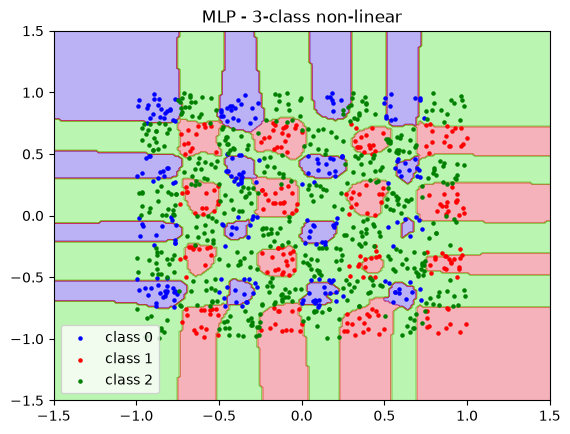

<Figure size 640x480 with 0 Axes>

In [3]:
X = np.random.random((1000,2))*2.0-1.0
Y = np.array([[1,-1,-1] if abs(p[0]%0.5)<=0.25 and abs(p[1]%0.5)>0.25 else
              [-1,1,-1] if abs(p[0]%0.5)>0.25 and abs(p[1]%0.5)<=0.25 else
              [-1,-1,1] for p in X])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y, dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 64, 64, 3])
mlp = mlp_lib.mlp_create(layers, 4, b"tanh", b"tanh")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    30000, 0.01)

out = ffi_mlp.new("uint32_t[]", X_f.shape[0])
mlp_lib.mlp_predict_classes(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
expected = np.argmax(Y, axis=1)
print("OK" if np.array_equal(preds, expected) else "KO")

x0 = np.linspace(-1.5, 1.5, 200)
x1 = np.linspace(-1.5, 1.5, 200)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.ascontiguousarray(np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32))
grid_out = ffi_mlp.new("uint32_t[]", grid.shape[0])
mlp_lib.mlp_predict_classes(mlp, ffi_mlp.from_buffer("float[]", grid), grid.shape[0], grid.shape[1], grid_out)
grid_preds = np.array(list(grid_out)).reshape(xx0.shape)

mlp_lib.mlp_destroy(mlp)

plt.contourf(xx0, xx1, grid_preds, alpha=0.3, cmap='brg')
plt.scatter(X_f[expected==0,0], X_f[expected==0,1], color='blue', label='class 0', s=5, zorder=3)
plt.scatter(X_f[expected==1,0], X_f[expected==1,1], color='red', label='class 1', s=5, zorder=3)
plt.scatter(X_f[expected==2,0], X_f[expected==2,1], color='green', label='class 2', s=5, zorder=3)
plt.legend()
plt.title("MLP - 3-class non-linear")
plt.show()
plt.clf()

## Regression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

[1.9999913  3.00000858]
OK


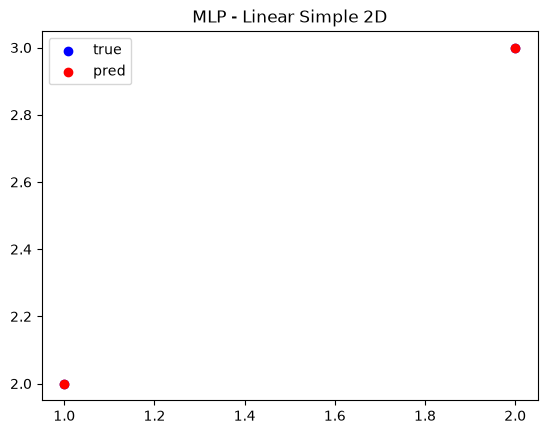

<Figure size 640x480 with 0 Axes>

In [4]:
X = np.array([[1],[2]])
Y = np.array([2,3])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [1, 1])
mlp = mlp_lib.mlp_create(layers, 2, b"tanh", b"identity")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    100000, 0.01)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
print(preds)
print("OK" if np.allclose(preds, Y, atol=0.5) else "KO")

mlp_lib.mlp_destroy(mlp)

plt.scatter(X_f, Y, color='blue', label='true', zorder=3)
plt.scatter(X_f, preds, color='red', label='pred', zorder=3)
plt.legend()
plt.title("MLP - Linear Simple 2D")
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

[2.00000095 2.99999619 2.50000262]
[2.  3.  2.5]
OK


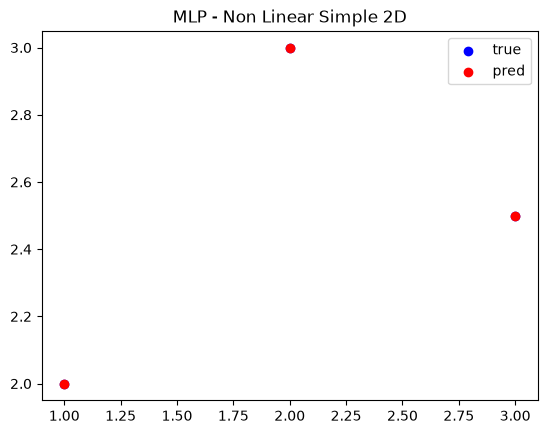

<Figure size 640x480 with 0 Axes>

In [5]:
X = np.array([[1],[2],[3]])
Y = np.array([2,3,2.5])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [1, 4, 1])
mlp = mlp_lib.mlp_create(layers, 3, b"tanh", b"identity")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    100000, 0.01)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
print(preds)
print(Y)
print("OK" if np.allclose(preds, Y, atol=0.5) else "KO")

mlp_lib.mlp_destroy(mlp)

plt.scatter(X_f, Y, color='blue', label='true', zorder=3)
plt.scatter(X_f, preds, color='red', label='pred', zorder=3)
plt.legend()
plt.title("MLP - Non Linear Simple 2D")
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

[1.9999913  3.00000405 2.49999976]
OK


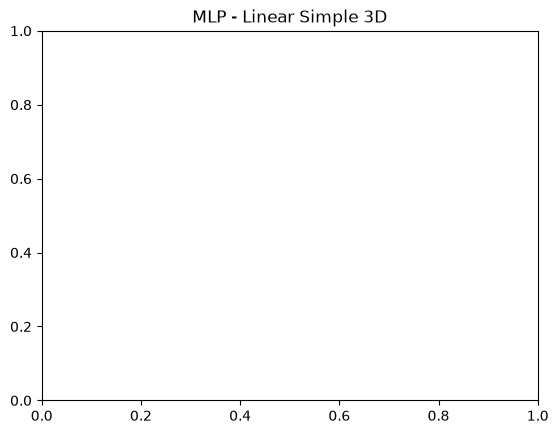

<Figure size 640x480 with 0 Axes>

In [8]:
X = np.array([[1,1],[2,2],[3,1]])
Y = np.array([2,3,2.5])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 1])
mlp = mlp_lib.mlp_create(layers, 2, b"tanh", b"identity")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    100000, 0.01)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
print(preds)
print("OK" if np.allclose(preds, Y, atol=0.5) else "KO")

mlp_lib.mlp_destroy(mlp)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X_f[:,0], X_f[:,1], Y, color='blue', label='true')
ax.scatter(X_f[:,0], X_f[:,1], preds, color='red', label='pred')
ax.legend()
plt.title("MLP - Linear Simple 3D")
plt.show()
plt.clf()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

[1.00000012 1.99999988 3.        ]
OK


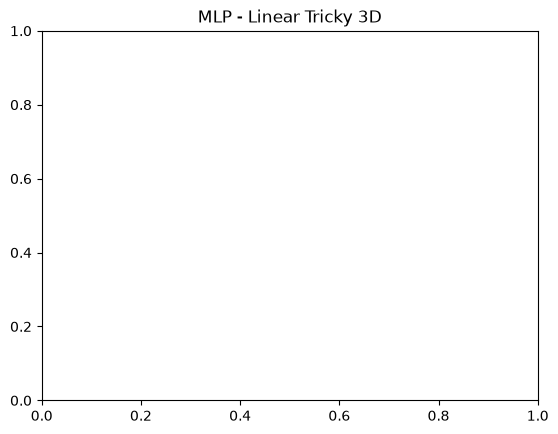

<Figure size 640x480 with 0 Axes>

In [9]:
X = np.array([[1,1],[2,2],[3,3]])
Y = np.array([1,2,3])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 1])
mlp = mlp_lib.mlp_create(layers, 2, b"tanh", b"identity")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    100000, 0.01)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
print(preds)
print("OK" if np.allclose(preds, Y, atol=0.5) else "KO")

mlp_lib.mlp_destroy(mlp)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X_f[:,0], X_f[:,1], Y, color='red', label='true')
ax.scatter(X_f[:,0], X_f[:,1], preds, color='blue', label='pred')
ax.legend()
plt.title("MLP - Linear Tricky 3D")
plt.show()
plt.clf()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

[ 1.99999857  0.99999762 -1.99999595 -0.99999738]
OK


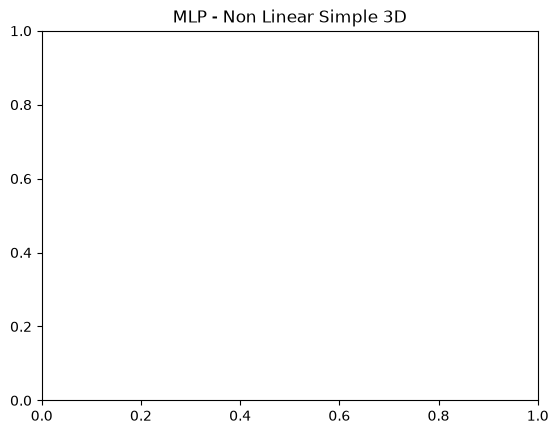

<Figure size 640x480 with 0 Axes>

In [10]:
X = np.array([[1,0],[0,1],[1,1],[0,0]])
Y = np.array([2,1,-2,-1])

X_f = np.ascontiguousarray(X, dtype=np.float32)
Y_f = np.ascontiguousarray(Y.reshape(-1,1), dtype=np.float32)

layers = ffi_mlp.new("uint32_t[]", [2, 2, 1])
mlp = mlp_lib.mlp_create(layers, 3, b"tanh", b"identity")
mlp_lib.mlp_train(mlp,
    ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1],
    ffi_mlp.from_buffer("float[]", Y_f), Y_f.shape[0], Y_f.shape[1],
    100000, 0.01)

out = ffi_mlp.new("float[]", X_f.shape[0])
mlp_lib.mlp_predict_raw(mlp, ffi_mlp.from_buffer("float[]", X_f), X_f.shape[0], X_f.shape[1], out)
preds = np.array(list(out))
print(preds)
print("OK" if np.allclose(preds, Y, atol=0.5) else "KO")

mlp_lib.mlp_destroy(mlp)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X_f[:,0], X_f[:,1], Y, color='blue', label='true')
ax.scatter(X_f[:,0], X_f[:,1], preds, color='red', label='pred')
ax.legend()
plt.title("MLP - Non Linear Simple 3D")
plt.show()
plt.clf()